# 1.1 — How Big Is "Big"?

**Chapter 1, section 1.5** (*How Big Is "Big"? Determining Whether a Cluster Is Necessary*).

**The question this notebook answers:** *how many bytes does this query read?* — not: how many
bytes do we own.

Section 1.5 argues that the volume an organization **stores** and the volume its queries
**scan** differ by orders of magnitude, and that a cluster is warranted only under four named
conditions. That is a quantitative claim, and it is a claim *against* the tool the rest of
this course teaches, so it should be measured rather than asserted. This notebook measures it
on a real table, on one laptop.

**Deliberately, there is no Spark in this notebook.** Opening a `SparkContext` in the notebook
that argues you probably do not need a cluster would undercut the argument. Everything here is
`pyarrow`, `pandas` and `duckdb`, all of which run inside this one Python process.

**What this notebook is not.** It measures the *size of the gap*. It does not take the gap
apart. Chapter 3 promises to quantify column pruning and predicate pushdown "later, when we
come to DataFrames and the Parquet format", and notebook **3.4 `Parquet vs CSV`** does exactly
that on this same dataset — three mechanisms separated, row-group sizing, codecs, write order,
and a scale check on the full 65.8-million-row extract. Read that one for *why*. This one is
for *how much*, and for the decision that follows from it.

Runs on a laptop in about a minute. It writes roughly 400 MB into a scratch directory.

## Setup

The data is the GDELT event extract that ships with the course: seven days of world news
events, **61 columns** per row. The width is the point — a query that touches six of
sixty-one columns has something to prune, which a five-column table does not.

In [1]:
# --- CS-777 session setup ------------------------------------------------
# Chapter 1, section 1.5.  NO SPARK: see the header cell.
import os, sys, time, tempfile, shutil, textwrap
import pyarrow as pa
import pyarrow.csv as pacsv
import pyarrow.parquet as pq
import pyarrow.dataset as ds
import pyarrow.compute as pc
import pandas as pd

DATA = os.environ.get("CS777_DATA", "../data")                       # -> code/data/
SCRATCH = os.environ.get("CS777_SCRATCH", os.path.join(tempfile.gettempdir(), "cs777"))
WORK = os.path.join(SCRATCH, "ch01-how-big")
os.makedirs(WORK, exist_ok=True)

GDELT = os.path.join(DATA, "gdelt")
SRC = os.path.join(GDELT, "gdelt-events-small.csv.gz")
SCHEMA_TXT = os.path.join(GDELT, "gdelt-schema.txt")

MB = 1024 * 1024

def mb(n_bytes):
    return n_bytes / MB

def dir_bytes(path):
    """Total size on disk of a file or of a directory tree."""
    if os.path.isfile(path):
        return os.path.getsize(path)
    return sum(os.path.getsize(os.path.join(r, f))
               for r, _, fs in os.walk(path) for f in fs)

def short(path, keep=3):
    """Last few path components -- enough to identify a location without printing
    somebody's home directory into a committed notebook."""
    parts = os.path.normpath(path).split(os.sep)
    return os.path.join(*parts[-keep:]) if len(parts) > keep else path

print("python  :", sys.version.split()[0])
print("pyarrow :", pa.__version__)
print("data    :", GDELT, f"(...{os.sep}{short(os.path.abspath(GDELT))})")
print("scratch :", f"...{os.sep}{short(WORK)}")
print("spark   : not started, and that is the point of this notebook")

python  : 3.12.14
pyarrow : 25.0.1
data    : ../data/gdelt (.../code/data/gdelt)
scratch : .../T/cs777/ch01-how-big
spark   : not started, and that is the point of this notebook


## 1. Bytes stored

The first number. This is what an organization would quote if you asked how big its data is.

The shipped file is gzipped, so we decompress it into the scratch directory as plain CSV
first: gzip's compression ratio is a property of the archive, not of the problem, and mixing
it into the comparison would flatter Parquet for the wrong reason.

In [2]:
# Column names and types come from the schema file that ships beside the data.
_TYPES = {"long": pa.int64(), "integer": pa.int32(),
          "double": pa.float64(), "string": pa.string()}
NAMES, COLUMN_TYPES = [], {}
for line in open(SCHEMA_TXT):
    if line.startswith("#") or not line.strip():
        continue
    _pos, name, typ = line.rstrip("\n").split("\t")
    NAMES.append(name)
    COLUMN_TYPES[name] = _TYPES[typ]

t0 = time.time()
table = pacsv.read_csv(
    SRC,
    read_options=pacsv.ReadOptions(column_names=NAMES, block_size=1 << 26),
    parse_options=pacsv.ParseOptions(delimiter="\t", quote_char=False),
    convert_options=pacsv.ConvertOptions(column_types=COLUMN_TYPES,
                                         null_values=[""], strings_can_be_null=True),
)
print(f"read in {time.time() - t0:.1f}s")
print(f"rows    : {table.num_rows:,}")
print(f"columns : {table.num_columns}")

CSV_PATH = os.path.join(WORK, "gdelt.csv")
pacsv.write_csv(table, CSV_PATH)

BYTES_STORED = dir_bytes(CSV_PATH)
print(f"\nbytes stored (plain CSV) : {mb(BYTES_STORED):,.1f} MB")

read in 0.4s
rows    : 731,884
columns : 61



bytes stored (plain CSV) : 312.3 MB


## 2. Three physical layouts

The same rows, written three ways. Nothing is added or removed; only the arrangement on disk
changes.

* **CSV** — text, row by row.
* **Parquet** — columnar, Snappy-compressed, one file. Written in the order the rows arrive.
* **Parquet partitioned by `SQLDATE`** — one directory per event date, so that a filter on the
  date can skip whole directories without opening them.

The compression ratio between the first two is the smallest part of the gap we are chasing,
and it is worth naming as such so that it is not mistaken for the whole effect.

In [3]:
PARQUET_PATH = os.path.join(WORK, "gdelt.parquet")
PART_PATH = os.path.join(WORK, "gdelt_by_date")

# 100,000 rows per row group rather than Parquet's conventional ~128 MB.  This table is
# small: at the default setting the whole file would be one row group, and a reader would
# have nothing to skip.  Notebook 3.4 measures what that choice costs and buys.
pq.write_table(table, PARQUET_PATH, compression="snappy", row_group_size=100_000)

shutil.rmtree(PART_PATH, ignore_errors=True)
pq.write_to_dataset(table, PART_PATH, partition_cols=["SQLDATE"], compression="snappy")

sizes = {
    "CSV (plain text)":            dir_bytes(CSV_PATH),
    "Parquet (one file)":          dir_bytes(PARQUET_PATH),
    "Parquet partitioned by date": dir_bytes(PART_PATH),
}
for name, n in sizes.items():
    print(f"{name:30s} {mb(n):9,.1f} MB")
print(f"\nCSV -> Parquet compression alone: {sizes['CSV (plain text)'] / sizes['Parquet (one file)']:.1f}x")
print("That ratio is compression.  It is NOT the effect this section is about.")

CSV (plain text)                   312.3 MB
Parquet (one file)                  51.8 MB
Parquet partitioned by date         52.4 MB

CSV -> Parquet compression alone: 6.0x
That ratio is compression.  It is NOT the effect this section is about.


## 3. One realistic query

Six columns out of sixty-one, filtered to the most recent day in the extract, grouped, and
producing a handful of rows. This is deliberately the shape of **Exercise 1** in the same
chapter, and it is the shape most analytical queries actually have: narrow, recent, and
aggregated down to something a human can read.

> *For the most recent day, which countries generated the most events, and what was the
> average tone of the coverage?*

In [4]:
QUERY_COLUMNS = ["SQLDATE", "ActionGeo_CountryCode", "EventRootCode",
                 "NumMentions", "AvgTone", "GoldsteinScale"]
LAST_DAY = pc.max(table["SQLDATE"]).as_py()
print(f"most recent SQLDATE in the extract : {LAST_DAY}")
print(f"columns referenced                 : {len(QUERY_COLUMNS)} of {table.num_columns}")

def run_query(tbl):
    """The aggregation itself, applied to whatever subset of the table was read."""
    return (tbl.select(QUERY_COLUMNS)
               .filter(pc.equal(tbl["SQLDATE"], LAST_DAY))
               .group_by("ActionGeo_CountryCode")
               .aggregate([("NumMentions", "sum"), ("AvgTone", "mean"),
                           ("EventRootCode", "count")])
               .to_pandas()
               .sort_values("NumMentions_sum", ascending=False)
               .head(10))

answer = run_query(table)
matching = pc.sum(pc.cast(pc.equal(table["SQLDATE"], LAST_DAY), pa.int64())).as_py()
print(f"rows matching the filter           : {matching:,} of {table.num_rows:,} "
      f"({100 * matching / table.num_rows:.1f}%)")
print(f"rows in the answer                 : {len(answer)}\n")
print(answer.to_string(index=False))

most recent SQLDATE in the extract : 20240107
columns referenced                 : 6 of 61
rows matching the filter           : 74,272 of 731,884 (10.1%)
rows in the answer                 : 10

ActionGeo_CountryCode  NumMentions_sum  AvgTone_mean  EventRootCode_count
                   US            88651     -2.336745                19652
                   IS            27175     -5.074011                 7002
                   IN            22495     -1.227408                 4680
                 None            17765     -2.343968                 1948
                   UK            17323     -1.763430                 3509
                   NI            12849     -1.046433                 2873
                   AS             9254     -1.627680                 1300
                   CH             7349     -0.857882                 1458
                   BG             6846     -3.853073                 1219
                   CA             6748     -1.637607             

## 4. The instrument, and what it can and cannot see

Knowing what an instrument measures matters more than the number it reports.

For **CSV** there is nothing to measure. A text reader has to scan every byte of the file to
find the end of any field, so a query over CSV reads the whole file whatever it selects and
whatever it filters. Bytes scanned equals bytes stored, and a date filter changes nothing.

For **Parquet** the honest measurement is arithmetic on the file's own footer. Parquet records,
for every column chunk of every row group, the compressed size of that chunk and the minimum
and maximum value it contains. So the bytes a reader must fetch are exactly:

> the sum of the compressed sizes of the **wanted columns'** chunks, over the row groups whose
> recorded min/max do **not** exclude the filter.

That is what `bytes_scanned_parquet` below computes. It reimplements, from the metadata,
precisely what the reader does: column pruning and predicate pushdown. It is exact, and it
sees nothing else — it says nothing about CPU, decompression, or the cost of the aggregation
afterwards.

> **A metric that lies.** Spark's web interface reports a figure labelled *size of files read*.
> That is the size of the file **splits assigned to tasks**, not the bytes fetched, and it is
> therefore blind to column pruning: measured that way, CSV → Parquet looks like a 3×
> improvement, which is the compression ratio and nothing else. Notebook 3.4 returns to this.

In [5]:
def bytes_scanned_parquet(path, columns, day=None, date_column="SQLDATE"):
    """Bytes a Parquet reader must fetch, computed from the file footers.

    Sums the compressed size of each wanted column's chunk, over the row groups that the
    filter cannot rule out.  Returns (bytes, row_groups_read, row_groups_total).
    """
    files = ([path] if os.path.isfile(path)
             else sorted(os.path.join(r, f) for r, _, fs in os.walk(path)
                         for f in fs if f.endswith(".parquet")))
    total = read = 0
    groups_read = groups_total = 0
    for f in files:
        meta = pq.ParquetFile(f).metadata
        # A partitioned dataset encodes the date in the directory name, so the date
        # column is absent from the file itself; the pruning already happened above.
        present = set(meta.schema.names)
        wanted = [c for c in columns if c in present]
        for g in range(meta.num_row_groups):
            rg = meta.row_group(g)
            groups_total += 1
            keep = True
            if day is not None and date_column in present:
                for c in range(rg.num_columns):
                    col = rg.column(c)
                    if col.path_in_schema == date_column and col.is_stats_set:
                        st = col.statistics
                        keep = st.min <= day <= st.max
                        break
            if not keep:
                continue
            groups_read += 1
            for c in range(rg.num_columns):
                col = rg.column(c)
                if col.path_in_schema in wanted:
                    read += col.total_compressed_size
    return read, groups_read, groups_total

def partition_dirs_touched(root, day):
    """How many partition directories a date filter leaves to open, and how many exist."""
    all_dirs = [d for d in os.listdir(root) if d.startswith("SQLDATE=")]
    kept = [d for d in all_dirs if d == f"SQLDATE={day}"]
    return len(kept), len(all_dirs)

print("instrument ready")

instrument ready


## 5. The measurement

Five runs of the same query. What changes is the layout the rows are read from and whether the
date filter is applied — nothing about the question being asked.

In [6]:
rows = []

REPEATS = 3

def timed(fn):
    """Best of three, in milliseconds.  These are laptop numbers and machine-dependent;
    they are here to show the shape of the difference, not to be quoted."""
    best, out = None, None
    for _ in range(REPEATS):
        t = time.perf_counter()
        out = fn()
        dt = (time.perf_counter() - t) * 1000
        best = dt if best is None else min(best, dt)
    return out, best

# 1. CSV, no filter.  Every byte, every column.
_, ms_ = timed(lambda: pacsv.read_csv(CSV_PATH).num_rows)
rows.append(("1. CSV, all columns, no filter", BYTES_STORED, dir_bytes(CSV_PATH), ms_, ""))

# 2. CSV, with the date filter.  A text reader still reads every byte to find the fields.
def csv_filtered():
    t = pacsv.read_csv(CSV_PATH)
    return run_query(t)
_, ms_ = timed(csv_filtered)
rows.append(("2. CSV, 6 columns, date filter", BYTES_STORED, dir_bytes(CSV_PATH), ms_,
             "a text reader cannot skip"))

# 3. Parquet, six columns, no filter.  Column pruning only.
n3, g3, gt3 = bytes_scanned_parquet(PARQUET_PATH, QUERY_COLUMNS)
_, ms_ = timed(lambda: ds.dataset(PARQUET_PATH).to_table(columns=QUERY_COLUMNS).num_rows)
rows.append(("3. Parquet, 6 columns, no filter", BYTES_STORED, n3, ms_,
             f"{g3}/{gt3} row groups"))

# 4. Parquet, six columns, date filter.  Column pruning + whatever the footer can skip.
n4, g4, gt4 = bytes_scanned_parquet(PARQUET_PATH, QUERY_COLUMNS, day=LAST_DAY)
_, ms_ = timed(lambda: run_query(
    ds.dataset(PARQUET_PATH).to_table(
        columns=QUERY_COLUMNS, filter=ds.field("SQLDATE") == LAST_DAY)))
rows.append(("4. Parquet, 6 columns, date filter", BYTES_STORED, n4, ms_,
             f"{g4}/{gt4} row groups"))

# 5. Parquet partitioned by date.  The filter is answered by the directory names.
kept, total_dirs = partition_dirs_touched(PART_PATH, LAST_DAY)
n5, g5, gt5 = bytes_scanned_parquet(os.path.join(PART_PATH, f"SQLDATE={LAST_DAY}"),
                                    QUERY_COLUMNS)
_, ms_ = timed(lambda: ds.dataset(PART_PATH, partitioning="hive").to_table(
    columns=[c for c in QUERY_COLUMNS if c != "SQLDATE"],
    filter=ds.field("SQLDATE") == LAST_DAY))
rows.append(("5. Parquet partitioned by date", BYTES_STORED, n5, ms_,
             f"{kept}/{total_dirs} directories opened"))

print("measured")

measured


## 6. The result

In [7]:
result = pd.DataFrame(rows, columns=["query", "bytes stored", "bytes scanned",
                                     "ms", "note"])
result["MB stored"] = (result["bytes stored"] / MB).round(1)
result["MB scanned"] = (result["bytes scanned"] / MB).round(3)
result["stored / scanned"] = (result["bytes stored"] / result["bytes scanned"]).round(0).astype(int)
result["ms"] = result["ms"].round(1)

print(result[["query", "MB stored", "MB scanned", "stored / scanned",
              "ms", "note"]].to_string(index=False))
print("\nThe ms column is best-of-three on this laptop, with the file in the page cache.")
print("It is machine-dependent.  The bytes columns are not: they are read from the")
print("Parquet footers and are the same wherever the file is opened.")

first, last = result["bytes scanned"].iloc[0], result["bytes scanned"].iloc[-1]
print(f"\nFirst row to last row: {mb(first):,.1f} MB -> {mb(last):,.2f} MB "
      f"= {first / last:,.0f}x fewer bytes read, for the same answer.")

                             query  MB stored  MB scanned  stored / scanned   ms                      note
    1. CSV, all columns, no filter      312.3     312.290                 1 85.5                          
    2. CSV, 6 columns, date filter      312.3     312.290                 1 87.6 a text reader cannot skip
  3. Parquet, 6 columns, no filter      312.3       4.034                77  2.3            8/8 row groups
4. Parquet, 6 columns, date filter      312.3       0.721               433  3.0            2/8 row groups
    5. Parquet partitioned by date      312.3       0.414               754  1.6   1/35 directories opened

The ms column is best-of-three on this laptop, with the file in the page cache.
It is machine-dependent.  The bytes columns are not: they are read from the
Parquet footers and are the same wherever the file is opened.

First row to last row: 312.3 MB -> 0.41 MB = 754x fewer bytes read, for the same answer.


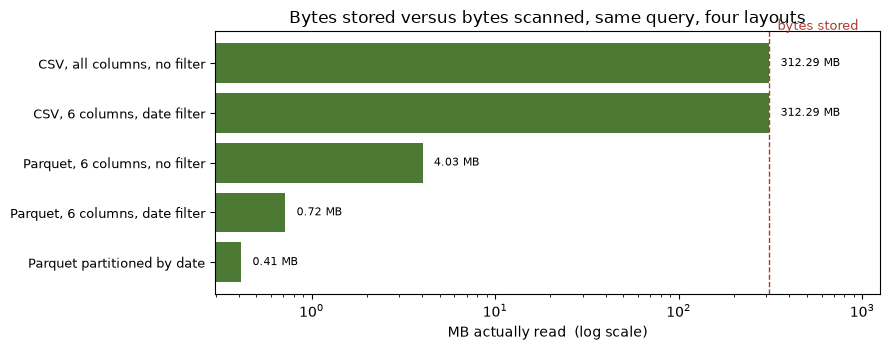

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.6))
labels = [q.split(". ", 1)[1] for q in result["query"]]
ax.barh(range(len(result)), result["bytes scanned"] / MB, color="#4C7A34")
ax.set_yticks(range(len(result)), labels, fontsize=9)
ax.invert_yaxis()
ax.set_xscale("log")
ax.set_xlabel("MB actually read  (log scale)")
ax.axvline(BYTES_STORED / MB, color="#B03A2E", linestyle="--", linewidth=1)
ax.text(BYTES_STORED / MB, -0.75, "  bytes stored", color="#B03A2E", fontsize=9, va="center")
for i, v in enumerate(result["bytes scanned"] / MB):
    ax.text(v * 1.15, i, f"{v:,.2f} MB", va="center", fontsize=8)
ax.set_title("Bytes stored versus bytes scanned, same query, four layouts")
ax.set_xlim(right=(BYTES_STORED / MB) * 4)
fig.tight_layout()
plt.show()

## 7. Does this workload need a cluster?

Section 1.5.3 gives four conditions, and a cluster is warranted when **at least one** holds.
Walk the workload just measured through them.

In [9]:
verdict = pd.DataFrame([
    ("1. The data does not fit on one machine",
     "NO",
     f"the job scans {mb(last):,.2f} MB, not the {mb(BYTES_STORED):,.0f} MB stored; "
     f"it fits in L3 cache, never mind memory"),
    ("2. The job must survive a machine dying",
     "NO",
     f"it finishes in {result['ms'].iloc[-1]:.0f} ms; if it fails, run it again"),
    ("3. The workload is a never-ending stream",
     "NO",
     "one bounded file, queried on demand"),
    ("4. The shuffle is genuinely wide",
     "NO",
     f"the group-by produces {len(answer)} rows shown out of a few hundred keys; "
     "the intermediate result is smaller than the input, not larger"),
], columns=["condition", "holds?", "why"])
print(verdict.to_string(index=False))
print("\nNone of the four conditions holds.  This workload does not need a cluster.")

                               condition holds?                                                                                                                          why
 1. The data does not fit on one machine     NO                                         the job scans 0.41 MB, not the 312 MB stored; it fits in L3 cache, never mind memory
 2. The job must survive a machine dying     NO                                                                               it finishes in 2 ms; if it fails, run it again
3. The workload is a never-ending stream     NO                                                                                          one bounded file, queried on demand
        4. The shuffle is genuinely wide     NO the group-by produces 10 rows shown out of a few hundred keys; the intermediate result is smaller than the input, not larger

None of the four conditions holds.  This workload does not need a cluster.


## 8. What one machine can actually do

Section 1.5.2 claims that "on data sets of tens of gigabytes, [DuckDB] frequently outperforms a
small Spark cluster", and that a single node is "typically faster, cheaper, and easier to
debug". Here is the same aggregation on this one machine, three ways, so the claim has a number
attached to it rather than a citation alone.

All three read the Parquet file. None of them starts a cluster, a scheduler, or a JVM.

In [10]:
import duckdb

results = []

# (a) pyarrow, as measured above.
_, ms_ = timed(lambda: run_query(
    ds.dataset(PARQUET_PATH).to_table(columns=QUERY_COLUMNS,
                                      filter=ds.field("SQLDATE") == LAST_DAY)))
results.append(("pyarrow (in-process, columnar)", ms_))

# (b) pandas.
def pandas_query():
    df = pd.read_parquet(PARQUET_PATH, columns=QUERY_COLUMNS)
    df = df[df["SQLDATE"] == LAST_DAY]
    return (df.groupby("ActionGeo_CountryCode")
              .agg(NumMentions_sum=("NumMentions", "sum"), AvgTone_mean=("AvgTone", "mean"))
              .sort_values("NumMentions_sum", ascending=False).head(10))
_, ms_ = timed(pandas_query)
results.append(("pandas (in-process, row-oriented)", ms_))

# (c) DuckDB, reading the Parquet file directly.
con = duckdb.connect()
SQL = f"""
    SELECT ActionGeo_CountryCode,
           sum(NumMentions) AS NumMentions_sum,
           avg(AvgTone)     AS AvgTone_mean,
           count(*)         AS events
    FROM read_parquet('{PARQUET_PATH}')
    WHERE SQLDATE = {LAST_DAY}
    GROUP BY 1 ORDER BY 2 DESC LIMIT 10
"""
duck_answer, ms_ = timed(lambda: con.execute(SQL).df())
results.append(("duckdb (in-process, vectorized)", ms_))

print(f"{'engine':36s}       ms")
for name, ms_ in results:
    print(f"{name:36s} {ms_:8.1f}")
print(f"\nDuckDB's answer, for comparison with section 3 above:\n")
print(duck_answer.to_string(index=False))
print("\nAll three are timed on the same laptop, and all are machine-dependent numbers.")
print("A Spark job over the same file would spend longer than any of them starting up.")

engine                                     ms
pyarrow (in-process, columnar)            3.3
pandas (in-process, row-oriented)        14.5
duckdb (in-process, vectorized)           1.9

DuckDB's answer, for comparison with section 3 above:

ActionGeo_CountryCode  NumMentions_sum  AvgTone_mean  events
                   US          88651.0     -2.336745   19652
                   IS          27175.0     -5.074011    7002
                   IN          22495.0     -1.227408    4680
                 None          17765.0     -2.343968    1948
                   UK          17323.0     -1.763430    3509
                   NI          12849.0     -1.046433    2873
                   AS           9254.0     -1.627680    1300
                   CH           7349.0     -0.857882    1458
                   BG           6846.0     -3.853073    1219
                   CA           6748.0     -1.637607    1257

All three are timed on the same laptop, and all are machine-dependent numbers.
A Spark j

## 9. Does the argument survive at scale?

The extract used above is the small one. The course also ships the full extract, and its
manifest records its size without our having to read it — which is itself the habit this
section is teaching.

In [11]:
import json
manifest = json.load(open(os.path.join(GDELT, "manifest.json")))
large, days = manifest["large"], manifest["days"]

# Rows on one day, here and there.  The small extract covers 7 days; the full one covers 531.
day_rows_small = matching
day_rows_large = sum(d["rows"] for d in days) / len(days)

print(f"{'':22s}{'rows':>14s}{'days':>7s}{'rows/day':>12s}{'stored as raw text':>22s}")
print(f"{'small extract':22s}{table.num_rows:>14,}{7:>7}{day_rows_small:>12,}"
      f"{mb(BYTES_STORED):>19,.0f} MB")
print(f"{'full extract':22s}{large['rows']:>14,}{len(days):>7}{day_rows_large:>12,.0f}"
      f"{large['raw_bytes'] / MB:>19,.0f} MB")

# The query filters to ONE day either way.  The table grew 90x; the day did not.
scale = day_rows_large / day_rows_small
projected = last * scale
print(f"\nThe table has {large['rows'] / table.num_rows:.0f}x more rows.  One day of it has "
      f"only {scale:.1f}x more.")
print(f"So the same query would scan on the order of {mb(projected):,.1f} MB, "
      f"against {large['raw_bytes'] / MB / 1024:,.1f} GB stored:")
print(f"\n    small extract : {BYTES_STORED / last:>9,.0f}x  stored / scanned")
print(f"    full extract  : {large['raw_bytes'] / projected:>9,.0f}x  stored / scanned  (projected)")
print("\nThe ratio does not collapse as the data grows -- it widens by roughly the same")
print("factor the data grew by, because the query keeps filtering to one day and keeps")
print("reading six columns while the table behind it gets longer.  That is the whole")
print("reason a 40 TB warehouse can be served by 2 GB queries.")
print("\nNotebook 3.4 measures this on the full extract instead of projecting it, and finds")
print("the same shape: column pruning alone takes 25 GiB to 257 MB, and a date predicate")
print("takes it to 3.9 MB by skipping 124 of 125 row groups.")

                                rows   days    rows/day    stored as raw text
small extract                731,884      7      74,272                312 MB
full extract              65,800,035    531     123,917             25,609 MB

The table has 90x more rows.  One day of it has only 1.7x more.
So the same query would scan on the order of 0.7 MB, against 25.0 GB stored:

    small extract :       754x  stored / scanned
    full extract  :    37,051x  stored / scanned  (projected)

The ratio does not collapse as the data grows -- it widens by roughly the same
factor the data grew by, because the query keeps filtering to one day and keeps
reading six columns while the table behind it gets longer.  That is the whole
reason a 40 TB warehouse can be served by 2 GB queries.

Notebook 3.4 measures this on the full extract instead of projecting it, and finds
the same shape: column pruning alone takes 25 GiB to 257 MB, and a date predicate
takes it to 3.9 MB by skipping 124 of 125 row groups

## Conclusion

The table in section 6 is the argument of chapter 1, section 1.5, in one place:

* **Bytes stored** and **bytes scanned** differ here by a factor of several hundred, for a
  query of an entirely ordinary shape — and the query is the *same query* throughout; only
  the arrangement of the bytes on disk changed.
* The reduction comes from three separate mechanisms, and they are not equal. Compression
  (CSV → Parquet) is the smallest. **Column pruning** — six columns of sixty-one — is much
  larger. **Partition pruning** — a filter answered by directory names — is larger again.
  Chapter 3 separates and measures them; here it is enough to see that the first of the three,
  the one everyone thinks of, is the least of them.
* Measured against the four conditions of §1.5.3, this workload justifies **no** cluster.

The habit to take away is the one in the chapter's note box: before provisioning anything,
instrument a representative query and find out how many bytes it actually reads. On this data
the answer was three orders of magnitude smaller than the number an inventory would have
reported.

**Next.** Chapter 1 continues to the MapReduce model and to the first distributed program
(notebook 1.2), which *is* Spark — because the conditions above do eventually hold, and the
rest of the course is about what to do when they do.